In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # avoids Windows OpenMP kernel crashes

!pip install -q transformers torch torchvision pillow requests matplotlib

In [2]:
import requests
from io import BytesIO

import torch
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

from transformers import ViTImageProcessor, ViTForImageClassification

In [3]:
model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)
model.eval()

print("Model loaded:", model_name)
print("Number of classes:", model.config.num_labels)

Model loaded: google/vit-base-patch16-224
Number of classes: 1000


In [4]:
# ---- Option A: load from local files ----
# Save 5 images next to this notebook with these exact filenames before running.

image_data = [
    ("dog.jpg", "dog"),
    ("cat.jpg", "cat"),
    ("elephant.jpg", "elephant"),
    ("mountain.jpg", "mountain"),
    ("apple.jpg", "apple"),
]

def load_image_local(path):
    img = Image.open(path)
    if img.mode == "P":
        img = img.convert("RGBA")
    return img.convert("RGB")

images = []
ground_truths = []

for path, label in image_data:
    try:
        img = load_image_local(path)
        images.append(img)
        ground_truths.append(label)
    except Exception as e:
        print(f"Failed on {path}: {e}")

print(f"Loaded {len(images)} images.")

Failed on cat.jpg: [Errno 2] No such file or directory: 'cat.jpg'
Failed on elephant.jpg: [Errno 2] No such file or directory: 'elephant.jpg'
Failed on mountain.jpg: [Errno 2] No such file or directory: 'mountain.jpg'
Failed on apple.jpg: [Errno 2] No such file or directory: 'apple.jpg'
Loaded 1 images.


In [5]:
# ---- Option B: download images from the web (only run if Option A files aren't available) ----
# NOTE: run this INSTEAD of Option A above, not after it, to avoid duplicate images.

web_image_data = [
    ("https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg", "dog"),
]

def load_image_from_url(url):
    headers = {"User-Agent": "MyResearchBot/1.0 (research; you@example.com)"}
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

# Uncomment to use:
# images = []
# ground_truths = []
# for url, label in web_image_data:
#     try:
#         img = load_image_from_url(url)
#         images.append(img)
#         ground_truths.append(label)
#     except Exception as e:
#         print(f"Failed on {url}: {e}")
# print(f"Loaded {len(images)} images.")

In [6]:
assert len(images) > 0, "No images loaded — add image files (Option A) or fix URLs (Option B) above before continuing."

In [7]:
def predict(image):
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)

    top_prob, top_idx = torch.max(probs, dim=-1)
    predicted_label = model.config.id2label[top_idx.item()]
    confidence = top_prob.item()
    return predicted_label, confidence

results = []
for img, gt in zip(images, ground_truths):
    pred_label, confidence = predict(img)
    results.append({
        "image": img,
        "ground_truth": gt,
        "predicted_class": pred_label,
        "confidence": confidence
    })

for r in results:
    print(f"True: {r['ground_truth']:12s} | Predicted: {r['predicted_class']:30s} | Confidence: {r['confidence']*100:.2f}%")

True: dog          | Predicted: golden retriever               | Confidence: 98.13%


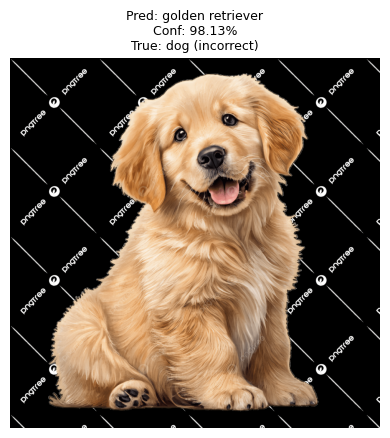

In [8]:
# Note: ImageNet (what ViT was trained on) uses specific breed/species names,
# e.g. "Labrador retriever" or "Samoyed" instead of the generic word "dog".
# is_correct() checks whether the ground-truth word appears in the predicted label,
# so it will mark e.g. "dog" -> "Samoyed" as incorrect even though it IS a dog breed.
# Adjust ground_truth labels to be more specific if you want stricter/looser matching.

def is_correct(ground_truth, predicted_class):
    gt_words = ground_truth.lower().replace("/", " ").split()
    pred = predicted_class.lower()
    return any(word in pred for word in gt_words)

for r in results:
    r["correct"] = is_correct(r["ground_truth"], r["predicted_class"])

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 5))
if len(images) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ax.imshow(r["image"])
    ax.axis("off")
    mark = "correct" if r["correct"] else "incorrect"
    title = f"Pred: {r['predicted_class']}\nConf: {r['confidence']*100:.2f}%\nTrue: {r['ground_truth']} ({mark})"
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
df = pd.DataFrame(results)
df["confidence"] = (df["confidence"] * 100).round(2).astype(str) + "%"
df = df[["ground_truth", "predicted_class", "confidence", "correct"]]
df.columns = ["Ground Truth", "Predicted Class", "Confidence", "Correct?"]
df

,Ground Truth,Predicted Class,Confidence,Correct?
0,dog,golden retriever,98.13%,False
